# 1.1-GEMM
GEMM is short for General Matrix Multiplication.
GEMM是通用矩阵乘法的缩写。

$A\in R^{m\times k}, B\in R^{k\times n}, C = A \times B, C\in R^{m\times n}$

## Profiler

测试框架已抽到 `test/` 包（`config` 常量与开关 / `gpu` 空闲GPU选择 / `registry` 注册表 / `verify` 正确性 / `benchmark` 性能 / `plot` 绘图 / `native` C++·CUDA编译加载）。notebook 只保留实现注册与测试调用。

In [ ]:
# ═══════════════════════════════════════════════════════════
# GEMM Profiler — framework import & GPU selection
# ═══════════════════════════════════════════════════════════
# 测试框架在 test/ 包中（config / gpu / registry / verify / benchmark /
# plot / native 七个模块），本 cell 只负责导入与 GPU 选择。

import os
import sys
import pathlib

import cupy as cp
import numpy as np
from cupy.cuda import cublas
import matplotlib.pyplot as plt

# 把 notebook 所在目录加入 sys.path，使 test 包可导入
_NB_FILE = globals().get("__vsc_ipynb_file__") or (globals().get("_dh") or [""])[0] or None
_NB_DIR = pathlib.Path(_NB_FILE).parent if _NB_FILE else pathlib.Path(os.getcwd())
if str(_NB_DIR) not in sys.path:
    sys.path.insert(0, str(_NB_DIR))

from test import *               # 注册表 / 验证 / 基准 / 绘图 / 原生库构建
import test.config as config     # 可动态修改的配置（见下）
from test.gpu import select_gpu

# 后端开关（默认在 test/config.py；也可在此动态覆盖）：
#   config.TEST_BACKENDS = "cpu"   # 仅 CPU
#   config.TEST_BACKENDS = "gpu"   # 仅 GPU
device = select_gpu()  # 自动选择空闲 GPU（CPU-only 模式下跳过）
if device is not None:
    print(f"cuBLAS version: {cublas.getVersion(device.cublas_handle)}")
print(f"CuPy: {cp.__version__}  |  NumPy: {np.__version__}")

## CPU Implementations

<!-- CPU 实现与 GPU 实现接入同一套注册机制，只需 `backend="cpu"`：

| | GPU (`backend="gpu"`) | CPU (`backend="cpu"`) |
|---|---|---|
| 数据 | CuPy 数组 | NumPy 数组 |
| 计时 | CUDA Event | `time.perf_counter` + 自适应迭代次数 |
| C/C++ 集成 | nvcc 编译 `gemm_gpu.cu` + `ctypes` 调用 | g++ 编译 `gemm_cpu.cpp` + `ctypes` 调用 |

- **Python**: NumPy BLAS（`@`）、einsum、纯 Python 三重循环
- **C++**: `gemm_cpu.cpp` 编译为 `libgemm_cpu.so`，经 ctypes 调用
- 慢实现用 `max_size` 门控，避免拖慢大矩阵扫描（如纯 Python 循环只测 ≤128） -->

### Python

In [ ]:
# ═══════════════════════════════════════════════════════════
# Python CPU Implementations
# ═══════════════════════════════════════════════════════════
from test.registry import register_gemm, list_implementations

if config.TEST_BACKENDS in ("all", "cpu"):

    @register_gemm("NumPy BLAS", backend="cpu")
    def numpy_blas_gemm(M: int, N: int, K: int,
                        A: np.ndarray, B: np.ndarray) -> np.ndarray:
        """NumPy matmul — calls the optimized multithreaded BLAS. The CPU baseline."""
        return A @ B


    @register_gemm("NumPy einsum", backend="cpu", warmup=2)
    def numpy_einsum_gemm(M: int, N: int, K: int,
                          A: np.ndarray, B: np.ndarray) -> np.ndarray:
        """np.einsum without the optimization path (pure einsum machinery)."""
        return np.einsum("ik,kj->ij", A, B, optimize=False)


    @register_gemm("Python triple loop", backend="cpu",
                   max_size=128, warmup=0, iters=1)
    def python_naive_gemm(M: int, N: int, K: int,
                          A: np.ndarray, B: np.ndarray) -> np.ndarray:
        """Pure-Python ijk loop — for education only, ~0.001 GFLOPS.

        Gated to sizes ≤ 128 (max_size) so it doesn't stall the sweep.
        """
        A = np.asarray(A, dtype=DTYPE_NP)
        B = np.asarray(B, dtype=DTYPE_NP)
        C = np.zeros((M, N), dtype=DTYPE_NP)
        for i in range(M):
            for j in range(N):
                for k in range(K):
                    C[i,j] += A[i,k] * B[k, j]
        return C


    print(f"Registered: {list_implementations()}")
else:
    print("GPU-only mode: skipping Python CPU implementations.")

### C++

C++ 实现在 `gemm_cpu.cpp` 中；编译、加载与注册由 `test/native.py` 的 `prepare_all()` 自动完成（版本化产物 + mtime 缓存）。

Naive Implementations just use three loops.

TILING: Save how much?

suppose $A, B, C\in R^{N\times N}$, method ikj = $N^3+N^2$, tile stores the $B\times B$ block in the cache.

Then, tile will read $(N/B)^3\times 2B^2 = 2N^3 / B$

## GPU kernels

GPU 实现注册为 `backend="gpu"`（默认值）：数据为 CuPy 数组，计时用 CUDA Event。

Kernel 代码在 `gemm_gpu.cu` 中（nvcc 编译为版本化的 `gemm_gpu.<mtime>-<size>.so`）。`prepare_all()` 会检测源码是否比编译产物新，过期则自动重编译并重载——所以改完 `.cu` 只需直接重跑 Results cell。
`__global__` kernel 不能直接被 ctypes 调用，因此每个 kernel 配一个 `extern "C"` 的 host launcher，在调用方提供的 stream 上启动（保证 CUDA Event 计时正确）。

新 kernel 的接入方式：`.cu` 中写 kernel + launcher → 在 `test/native.py` 的 `CU_IMPLS` 清单中加一行 `("launcher 名", "显示名")`。

In [ ]:
# ═══════════════════════════════════════════════════════════
# cuBLAS Baseline — using raw cuBLAS handle
# ═══════════════════════════════════════════════════════════

if config.TEST_BACKENDS in ("all", "gpu"):

    # Pre-allocate host scalars for cuBLAS (alpha/beta must be passed as pointers)
    _alpha = np.array([1.0], dtype=DTYPE_NP)
    _beta = np.array([0.0], dtype=DTYPE_NP)


    @register_gemm("cuBLAS")
    def cublas_sgemm(M: int, N: int, K: int,
                     A: cp.ndarray, B: cp.ndarray) -> cp.ndarray:
        """cuBLAS SGEMM baseline.

        Uses the column-major trick:
          C_row(M×N) = A_row(M×K) @ B_row(K×N)
          → C_col(N×M) = B_col(N×K) @ A_col(K×M) in cuBLAS
        """
        handle = cp.cuda.Device().cublas_handle
        C = cp.zeros((M, N), dtype=DTYPE)

        cublas.sgemm(handle,
            cublas.CUBLAS_OP_N, cublas.CUBLAS_OP_N,
            N, M, K,                            # m=N, n=M, k=K
            _alpha.ctypes.data, B.data.ptr, N,   # A_arg = B_col(NxK), lda=N
            A.data.ptr, K,                        # B_arg = A_col(KxM), ldb=K
            _beta.ctypes.data, C.data.ptr, N)     # C_col(NxM), ldc=N

        return C


    @register_gemm("cuBLAS (cupy)")
    def cublas_cupy_sgemm(M: int, N: int, K: int,
                          A: cp.ndarray, B: cp.ndarray) -> cp.ndarray:
        """cuBLAS via cp.matmul — convenience wrapper, includes minor overhead."""
        return cp.matmul(A, B)


    print(f"Registered: {list_implementations()}")
else:
    print("CPU-only mode: skipping cuBLAS baseline.")

In [ ]:
# ═══════════════════════════════════════════════════════════
# Native implementations — C++/CUDA build, load & register
# ═══════════════════════════════════════════════════════════
# 实现清单在 test/native.py（CPP_IMPLS / CU_IMPLS）。prepare_all() 按源码
# mtime 检查过期产物、自动重编译并重载、重新注册；Results cells 也会调用
# 它——改完 gemm_cpu.cpp / gemm_gpu.cu 后直接重跑 Results 即可。

prepare_all()

## Results

### Step 1: Verify Correctness

Run this cell to check the correctness of GEMM implementation. 
The baseline is NumPy FP32.

In [13]:
# Verify all registered implementations
# 只验证某个后端：verify_all(backends="gpu")  # 或 "cpu"
# prepare_all() 会检查 .so 是否过期，过期则自动重编译并重载——
# 改完 gemm_gpu.cu / gemm_cpu.cpp 后直接重跑本 cell 即可
prepare_all()
verify_result = verify_all(backends="gpu")
print(verify_result.to_table())

Ready: 11 implementations registered.
Verifying backends: ['gpu']
--------------------------------------------------------------------------------------------------
Implementation         Backend  M      N      K      Time(ms)     GFLOPS       MaxErr       Pass  
--------------------------------------------------------------------------------------------------
cuBLAS                 gpu      128    128    128    0.0000       0.0          0.000019     ✓     
cuBLAS                 gpu      256    256    256    0.0000       0.0          0.000042     ✓     
cuBLAS                 gpu      512    512    512    0.0000       0.0          0.000061     ✓     
cuBLAS                 gpu      1024   1024   1024   0.0000       0.0          0.000099     ✓     
cuBLAS                 gpu      256    512    128    0.0000       0.0          0.000027     ✓     
cuBLAS                 gpu      512    256    1024   0.0000       0.0          0.000088     ✓     
cuBLAS (cupy)          gpu      128    128 

### Step 2: Benchmark Sweep

方形矩阵扫描 128 → 8192，覆盖已注册实现。

- 后端选择：默认跟随 `config.TEST_BACKENDS`（"all" / "gpu" / "cpu"，在 `test/config.py` 或第一个 cell 设置）；也可在此单独指定：`benchmark_all(SQUARE_SIZES, backends="gpu")` 或 `"cpu"`
- GPU：CUDA Event 计时，固定迭代次数
- CPU：`perf_counter` 计时，自适应迭代次数（每个数据点约 1.5s）
- 带 `max_size` 门控的实现自动跳过过大尺寸（如纯 Python 循环）

In [14]:
# Define sweep sizes (square matrices)
SQUARE_SIZES = [
    (128, 128, 128),
    (256, 256, 256),
    (512, 512, 512),
    (1024, 1024, 1024),
    (2048, 2048, 2048),
    (4096, 4096, 4096),
    (8192, 8192, 8192),
]

# 自动重编译过期产物——改 gemm_gpu.cu / gemm_cpu.cpp 后直接重跑本 cell 即可
prepare_all()

print("=" * 70)
print("GEMM Benchmark Sweep")
print("=" * 70)

# 默认跟随 TEST_BACKENDS；也可单独指定后端：
#   sweep = benchmark_all(SQUARE_SIZES, backends="gpu")   # 仅 GPU
#   sweep = benchmark_all(SQUARE_SIZES, backends="cpu")   # 仅 CPU
sweep = benchmark_all(SQUARE_SIZES, backends="gpu")

Ready: 11 implementations registered.
GEMM Benchmark Sweep
Benchmarking backends: ['gpu']
  Benchmarking cuBLAS               (128, 128, 128) ...   0.0166 ms     252.8 GFLOPS  ✓
  Benchmarking cuBLAS               (256, 256, 256) ...   0.0204 ms    1646.6 GFLOPS  ✓
  Benchmarking cuBLAS               (512, 512, 512) ...   0.0387 ms    6935.0 GFLOPS  ✓
  Benchmarking cuBLAS               (1024, 1024, 1024) ...   0.1666 ms   12893.6 GFLOPS  ✓
  Benchmarking cuBLAS               (2048, 2048, 2048) ...   1.2102 ms   14195.7 GFLOPS  ✓
  Benchmarking cuBLAS               (4096, 4096, 4096) ...   8.7597 ms   15689.9 GFLOPS  ✓
  Benchmarking cuBLAS               (8192, 8192, 8192) ...  57.4516 ms   19138.0 GFLOPS  ✓
  Benchmarking cuBLAS (cupy)        (128, 128, 128) ...   0.0148 ms     282.5 GFLOPS  ✓
  Benchmarking cuBLAS (cupy)        (256, 256, 256) ...   0.0189 ms    1776.0 GFLOPS  ✓
  Benchmarking cuBLAS (cupy)        (512, 512, 512) ...   0.0281 ms    9549.9 GFLOPS  ✓
  Benchmarking cuB

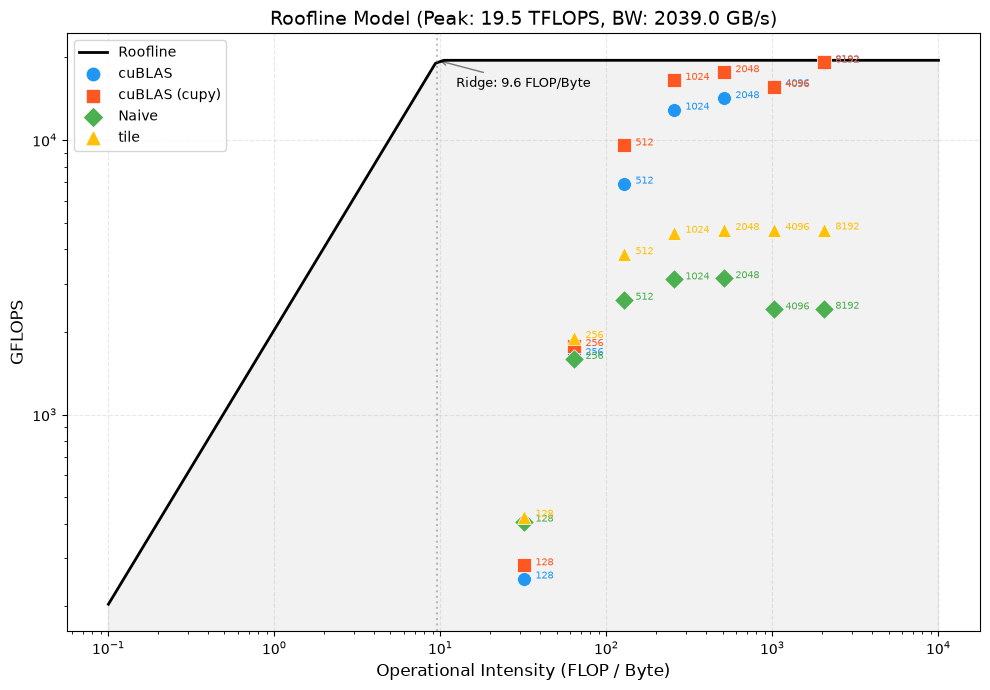


--------------------------------------------------------------------------------------------------
Implementation         Backend  M      N      K      Time(ms)     GFLOPS       MaxErr       Pass  
--------------------------------------------------------------------------------------------------
cuBLAS                 gpu      128    128    128    0.0166       252.8        0.000019     ✓     
cuBLAS                 gpu      256    256    256    0.0204       1646.6       0.000042     ✓     
cuBLAS                 gpu      512    512    512    0.0387       6935.0       0.000061     ✓     
cuBLAS                 gpu      1024   1024   1024   0.1666       12893.6      0.000099     ✓     
cuBLAS                 gpu      2048   2048   2048   1.2102       14195.7      0.000488     ✓     
cuBLAS                 gpu      4096   4096   4096   8.7597       15689.9      0.000977     ✓     
cuBLAS                 gpu      8192   8192   8192   57.4516      19138.0      0.002563     ✓     
cuBLAS (c

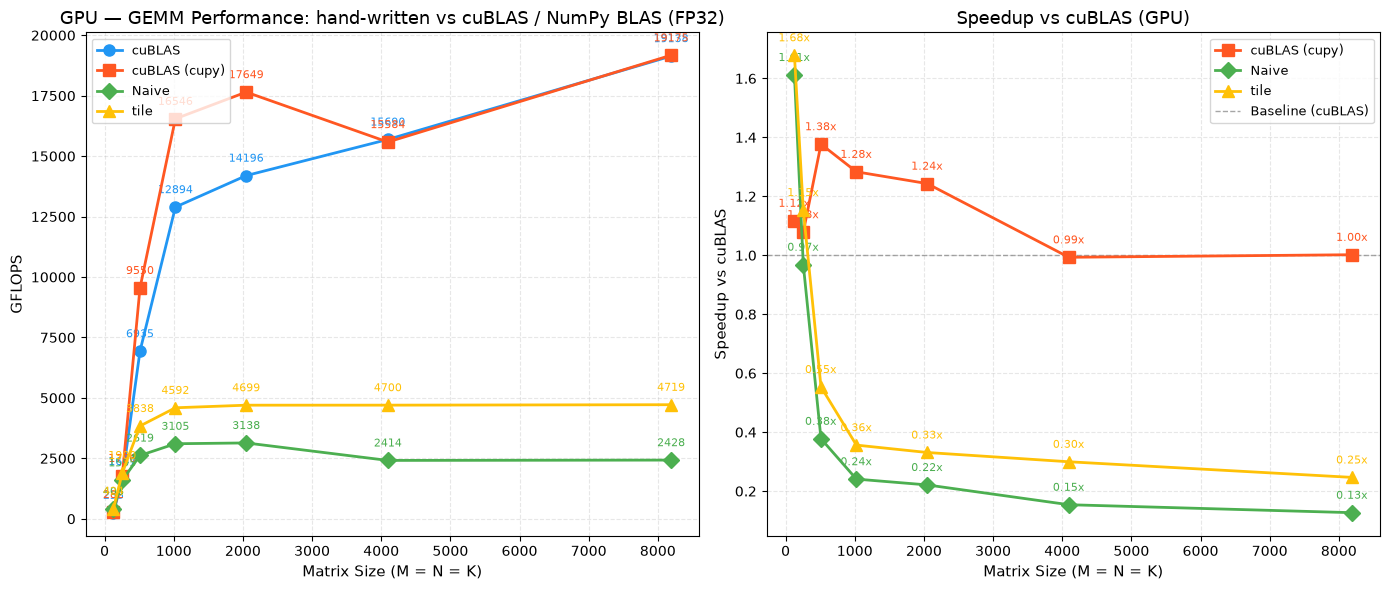

In [15]:
fig = plot_roofline(sweep)
plt.show()

print()
print(sweep.to_table())

# Plot — one row per backend (GPU / CPU)
fig = plot_gemm_comparison(
    sweep,
    title="GEMM Performance: hand-written vs cuBLAS / NumPy BLAS (FP32)")
plt.show()